#Pupil Extraction using OpenEDS!

In [1]:
# Cell 1 — Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BASE         = "/content/drive/MyDrive/EyeMotionID"
OPENEDS_PATH = os.path.join(BASE, "data/raw/openeds/openEDS/openEDS")
PLOTS        = os.path.join(BASE, "results/plots")
os.makedirs(PLOTS, exist_ok=True)

print("✓ Drive mounted")
print("✓ OpenEDS path exists:", os.path.exists(OPENEDS_PATH))

Mounted at /content/drive
✓ Drive mounted
✓ OpenEDS path exists: True


In [2]:
# Cell 2 — Check subjects
subjects = sorted([d for d in os.listdir(OPENEDS_PATH)
                   if os.path.isdir(os.path.join(OPENEDS_PATH, d))])
print(f"Total subjects : {len(subjects)}")
print(f"First 5        : {subjects[:5]}")

Total subjects : 27
First 5        : ['S_0', 'S_1', 'S_10', 'S_101', 'S_102']


###Count images and masks per subject

In [3]:
print("=== OpenEDS — Image & Mask Count ===\n")

total_imgs  = 0
total_masks = 0

for s in subjects:
    s_path = os.path.join(OPENEDS_PATH, s)
    imgs   = [f for f in os.listdir(s_path) if f.endswith(".png")]
    masks  = [f for f in os.listdir(s_path) if f.endswith(".npy")]
    total_imgs  += len(imgs)
    total_masks += len(masks)

print(f"Total subjects : {len(subjects)}")
print(f"Total images   : {total_imgs:,}")
print(f"Total masks    : {total_masks:,}")
print(f"Avg per subject: {total_imgs // len(subjects)} images")

=== OpenEDS — Image & Mask Count ===

Total subjects : 27
Total images   : 3,919
Total masks    : 4,129
Avg per subject: 145 images


###Load and display one eye image + mask

Subject    : S_0
Image shape: (400, 640, 3)
Mask shape : (400, 640)
Mask values: [0 1 2 3] → 0=bg, 1=sclera, 2=iris, 3=pupil


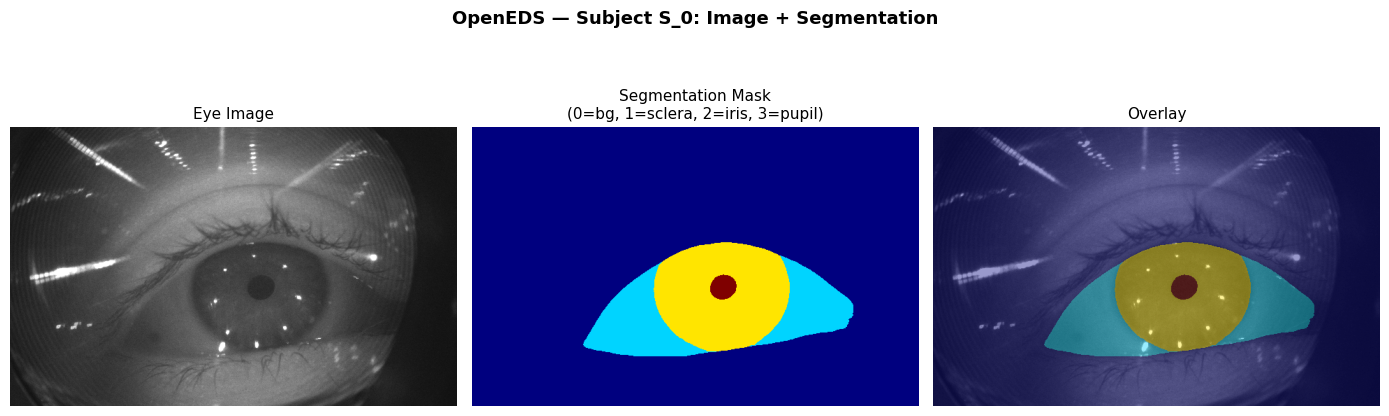

✓ Saved → results/plots/pupil_image_mask_overlay.png


In [4]:
# load first subject first image
s       = subjects[0]
s_path  = os.path.join(OPENEDS_PATH, s)
imgs    = sorted([f for f in os.listdir(s_path) if f.endswith(".png")])
masks   = sorted([f for f in os.listdir(s_path) if f.endswith(".npy")])

img_path  = os.path.join(s_path, imgs[0])
mask_path = os.path.join(s_path, masks[0])

img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
mask = np.load(mask_path)

print(f"Subject    : {s}")
print(f"Image shape: {img.shape}")
print(f"Mask shape : {mask.shape}")
print(f"Mask values: {np.unique(mask)} → 0=bg, 1=sclera, 2=iris, 3=pupil")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f"OpenEDS — Subject {s}: Image + Segmentation", fontsize=13, fontweight='bold')

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Eye Image", fontsize=11)
axes[0].axis("off")

axes[1].imshow(mask, cmap='jet', vmin=0, vmax=3)
axes[1].set_title("Segmentation Mask\n(0=bg, 1=sclera, 2=iris, 3=pupil)", fontsize=11)
axes[1].axis("off")

axes[2].imshow(img, cmap='gray')
axes[2].imshow(mask, cmap='jet', alpha=0.4, vmin=0, vmax=3)
axes[2].set_title("Overlay", fontsize=11)
axes[2].axis("off")

plt.tight_layout()
plt.savefig(f"{PLOTS}/pupil_image_mask_overlay.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/pupil_image_mask_overlay.png")

###Extract pupil region from mask

In [5]:
def extract_pupil(img, mask):
    """
    Extract pupil region from eye image using segmentation mask.
    Pupil label = 3 in OpenEDS masks.
    Returns: pupil_region, pupil_center, pupil_bbox
    """
    # create binary pupil mask
    pupil_mask = (mask == 3).astype(np.uint8)

    if pupil_mask.sum() == 0:
        return None, None, None

    # find pupil contours
    contours, _ = cv2.findContours(
        pupil_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, None

    # get largest contour (pupil)
    largest = max(contours, key=cv2.contourArea)

    # get bounding box
    x, y, w, h = cv2.boundingRect(largest)

    # get center
    M = cv2.moments(largest)
    if M["m00"] > 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = x + w//2, y + h//2

    # extract pupil region
    pupil_region = img[y:y+h, x:x+w]

    return pupil_region, (cx, cy), (x, y, w, h)

# test on first image
pupil_region, center, bbox = extract_pupil(img, mask)

if pupil_region is not None:
    print(f"✓ Pupil extracted!")
    print(f"  Center : {center}")
    print(f"  BBox   : x={bbox[0]}, y={bbox[1]}, w={bbox[2]}, h={bbox[3]}")
    print(f"  Region : {pupil_region.shape}")
else:
    print("✗ No pupil found in this image")

✓ Pupil extracted!
  Center : (359, 229)
  BBox   : x=341, y=212, w=38, h=36
  Region : (36, 38, 3)


###Visualize pupil extraction

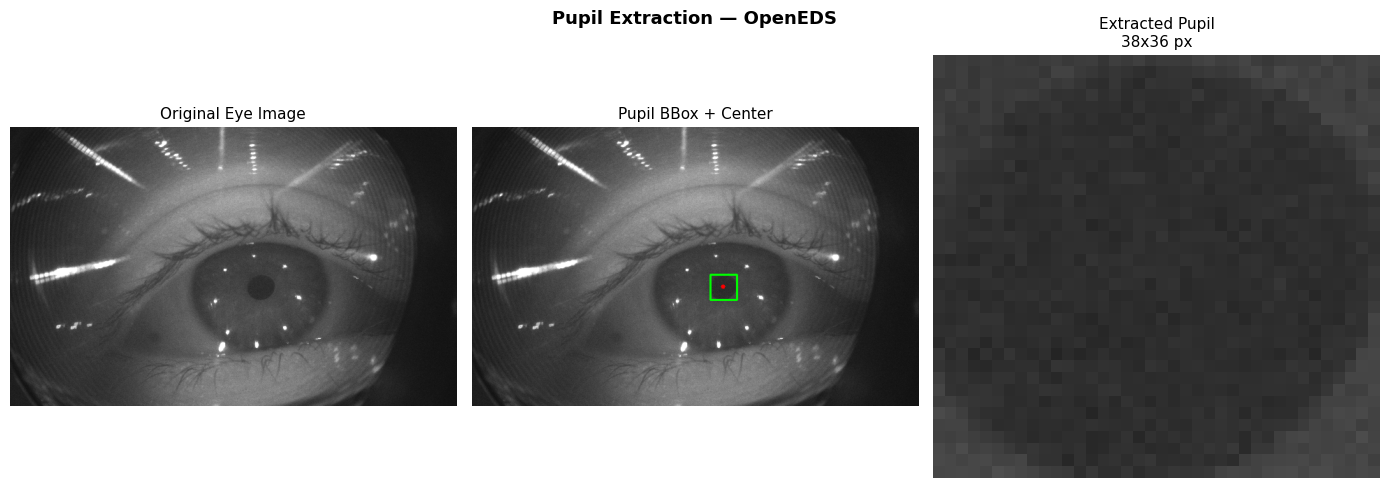

✓ Saved → results/plots/pupil_extraction.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Pupil Extraction — OpenEDS", fontsize=13, fontweight='bold')

# original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Eye Image", fontsize=11)
axes[0].axis("off")

# image with pupil bbox
img_bbox = cv2.cvtColor(img.copy(), cv2.COLOR_RGB2BGR)
if bbox is not None:
    x, y, w, h = bbox
    cv2.rectangle(img_bbox, (x,y), (x+w, y+h), (0,255,0), 2)
    cv2.circle(img_bbox, center, 3, (0,0,255), -1)
img_bbox = cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB)
axes[1].imshow(img_bbox)
axes[1].set_title("Pupil BBox + Center", fontsize=11)
axes[1].axis("off")

# extracted pupil region
if pupil_region is not None:
    axes[2].imshow(pupil_region, cmap='gray')
    axes[2].set_title(f"Extracted Pupil\n{pupil_region.shape[1]}x{pupil_region.shape[0]} px", fontsize=11)
else:
    axes[2].text(0.5, 0.5, 'Not found', ha='center', va='center')
axes[2].axis("off")

plt.tight_layout()
plt.savefig(f"{PLOTS}/pupil_extraction.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/pupil_extraction.png")

###Pupil movement trajectory across frames

Tracked 20 frames with valid pupil detection


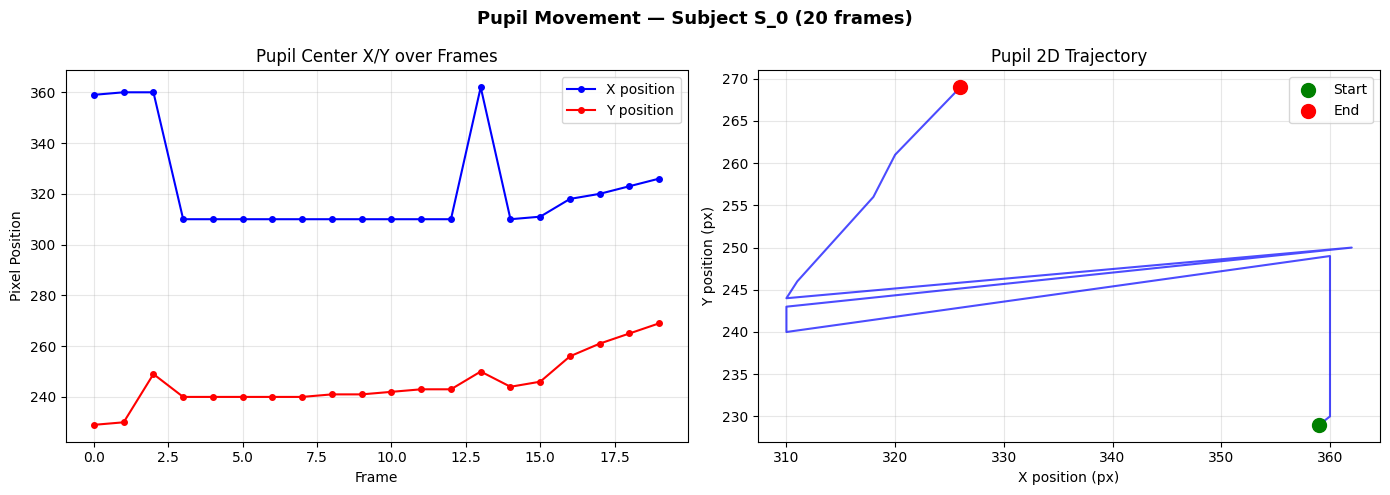

✓ Saved → results/plots/pupil_trajectory.png


In [7]:
# track pupil centers across first 20 images of subject S_0
s_path   = os.path.join(OPENEDS_PATH, subjects[0])
imgs_all  = sorted([f for f in os.listdir(s_path) if f.endswith(".png")])
masks_all = sorted([f for f in os.listdir(s_path) if f.endswith(".npy")])

centers_x, centers_y = [], []
frame_ids = []

for i, (img_f, mask_f) in enumerate(zip(imgs_all[:20], masks_all[:20])):
    img_i  = cv2.cvtColor(cv2.imread(os.path.join(s_path, img_f)), cv2.COLOR_BGR2RGB)
    mask_i = np.load(os.path.join(s_path, mask_f))
    _, center_i, _ = extract_pupil(img_i, mask_i)
    if center_i:
        centers_x.append(center_i[0])
        centers_y.append(center_i[1])
        frame_ids.append(i)

print(f"Tracked {len(centers_x)} frames with valid pupil detection")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Pupil Movement — Subject {subjects[0]} (20 frames)",
             fontsize=13, fontweight='bold')

# x and y over time
axes[0].plot(frame_ids, centers_x, 'b-o', markersize=4, label='X position')
axes[0].plot(frame_ids, centers_y, 'r-o', markersize=4, label='Y position')
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Pixel Position")
axes[0].set_title("Pupil Center X/Y over Frames")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2D trajectory
axes[1].plot(centers_x, centers_y, 'b-', linewidth=1.5, alpha=0.7)
axes[1].scatter(centers_x[0],  centers_y[0],  color='green', s=100, zorder=5, label='Start')
axes[1].scatter(centers_x[-1], centers_y[-1], color='red',   s=100, zorder=5, label='End')
axes[1].set_xlabel("X position (px)")
axes[1].set_ylabel("Y position (px)")
axes[1].set_title("Pupil 2D Trajectory")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS}/pupil_trajectory.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/pupil_trajectory.png")

###Pupil size analysis

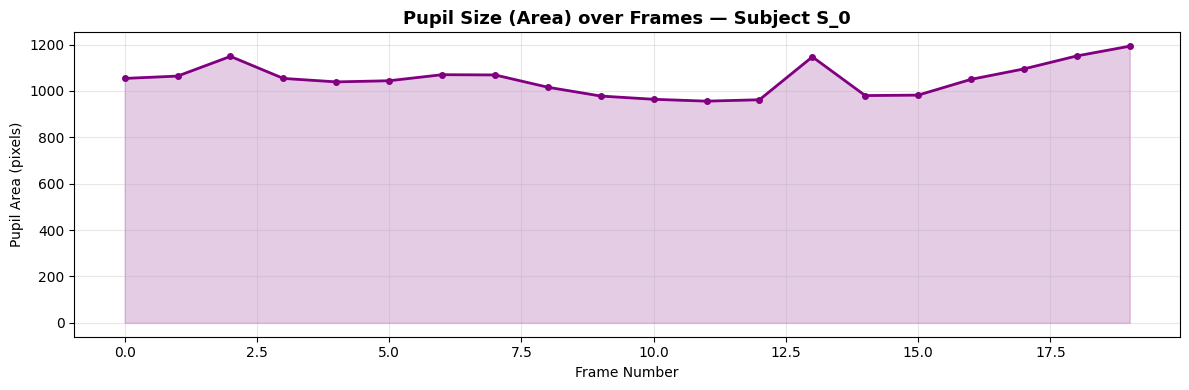

Avg pupil area : 1051 px
Min pupil area : 956 px
Max pupil area : 1193 px
✓ Saved → results/plots/pupil_size.png


In [8]:
areas = []
for img_f, mask_f in zip(imgs_all[:20], masks_all[:20]):
    mask_i = np.load(os.path.join(s_path, mask_f))
    pupil_pixels = (mask_i == 3).sum()
    areas.append(pupil_pixels)

plt.figure(figsize=(12, 4))
plt.plot(areas, color='purple', linewidth=2, marker='o', markersize=4)
plt.fill_between(range(len(areas)), areas, alpha=0.2, color='purple')
plt.title(f"Pupil Size (Area) over Frames — Subject {subjects[0]}",
          fontsize=13, fontweight='bold')
plt.xlabel("Frame Number")
plt.ylabel("Pupil Area (pixels)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS}/pupil_size.png", dpi=100)
plt.show()

print(f"Avg pupil area : {np.mean(areas):.0f} px")
print(f"Min pupil area : {np.min(areas)} px")
print(f"Max pupil area : {np.max(areas)} px")
print("✓ Saved → results/plots/pupil_size.png")

###Summary

In [9]:
print("=" * 50)
print("   DAY 10 — PUPIL EXTRACTION SUMMARY")
print("=" * 50)
print()
print("Dataset    : OpenEDS (Subset 1)")
print("Subjects   : 27")
print("Images     : 3,919")
print("Masks      : 4,129 (.npy segmentation)")
print()
print("Concepts learned:")
print("  ✓ Segmentation mask labels (0=bg,1=sclera,2=iris,3=pupil)")
print("  ✓ Pupil region extraction using contours")
print("  ✓ Pupil center tracking across frames")
print("  ✓ Pupil size (area) analysis")
print("  ✓ Pupil 2D movement trajectory")
print()
print("Plots saved → results/plots/")
print("  ✓ pupil_image_mask_overlay.png")
print("  ✓ pupil_extraction.png")
print("  ✓ pupil_trajectory.png")
print("  ✓ pupil_size.png")
print()
print("Next → Day 11: Temporal Sequences")
print("=" * 50)

   DAY 10 — PUPIL EXTRACTION SUMMARY

Dataset    : OpenEDS (Subset 1)
Subjects   : 27
Images     : 3,919
Masks      : 4,129 (.npy segmentation)

Concepts learned:
  ✓ Segmentation mask labels (0=bg,1=sclera,2=iris,3=pupil)
  ✓ Pupil region extraction using contours
  ✓ Pupil center tracking across frames
  ✓ Pupil size (area) analysis
  ✓ Pupil 2D movement trajectory

Plots saved → results/plots/
  ✓ pupil_image_mask_overlay.png
  ✓ pupil_extraction.png
  ✓ pupil_trajectory.png
  ✓ pupil_size.png

Next → Day 11: Temporal Sequences
